# Replot Truth-Recovery Artifacts

Load the saved ARES stage2 truth-recovery artifacts, optionally rerun the production artifact/plot generation from the saved bundle, recreate the critical-line, kappa, absolute-magnification, and aperture-mass recovery PDFs, and display the figures inline.


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

from lenscluster import plotting


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find repository root containing pyproject.toml")


REPO_ROOT = find_repo_root()
RUN_DIR_RELATIVE = Path(
    "results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 1000)S(1000, 500)maglikelihoodTrue/"
    "ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit"
)
RUN_DIR = REPO_ROOT / RUN_DIR_RELATIVE
OUTPUT_PDF = RUN_DIR / "ares_truth_recovery_critical_line_recovery.pdf"
KAPPA_OUTPUT_PDF = RUN_DIR / "ares_truth_recovery_kappa_model_truth_fractional_residual.pdf"
MU_OUTPUT_PDF = RUN_DIR / "ares_truth_recovery_mu_model_truth_fractional_residual.pdf"
APERTURE_OUTPUT_PDF = RUN_DIR / "ares_truth_recovery_m2d_aperture_ratio.pdf"
REFERENCE = (3, 0.0, 0.0)


def artifact_path(path: str | Path) -> Path:
    path = Path(path)
    return path if path.is_absolute() else REPO_ROOT / path


def require_file(path: str | Path) -> Path:
    resolved = artifact_path(path)
    if not resolved.is_file():
        raise FileNotFoundError(f"Required artifact does not exist: {resolved}")
    return resolved


require_file(RUN_DIR / "artifacts" / "plot_bundle.h5")
RUN_DIR

PosixPath('/home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 1000)S(1000, 500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit')

## Optional Artifact Regeneration

Set `REGENERATE_ARTIFACTS = True` to rerun the standard plots-only artifact generation from the saved `plot_bundle.h5` before the manual replot cells below. Leave it `False` to skip the expensive regeneration and only replot from the existing FITS/CSV artifacts.


In [18]:
REGENERATE_ARTIFACTS = True

if REGENERATE_ARTIFACTS:
    from lenscluster.cluster_solver import _load_artifacts, _rerender_plots
    from lenscluster.planning import SolverRuntime

    _, saved_runtime_args, _, _ = _load_artifacts(RUN_DIR / "artifacts")
    runtime_args = dict(saved_runtime_args)
    for fits_key in ("kappa_true_fits", "gammax_true_fits", "gammay_true_fits"):
        fits_value = runtime_args.get(fits_key)
        if fits_value is not None and str(fits_value).strip():
            runtime_args[fits_key] = str(require_file(fits_value))
    runtime_args.update(
        {
            "plots_only": True,
            "skip_plots": False,
            "show_plots": False,
            "quiet": False,
            # Regenerate truth-recovery artifacts only; image cutouts need local RGB FITS files.
            "image_catalog_family_cutouts": False,
            "image_catalog_family_cutout_image_dir": None,
            "image_catalog_family_cutout_bands": (),
        }
    )
    _rerender_plots(SolverRuntime(runtime_args), RUN_DIR)
else:
    print("Skipping artifact regeneration. Set REGENERATE_ARTIFACTS = True to rebuild tables/FITS/PDFs from the saved bundle.")


2026-06-25T17:19:14 [stage] ============ PLOTS ONLY: STAGE 2: stage2_free_source_forward_fit =============

2026-06-25T17:19:14 [stage] 
run_dir=/home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 
1000)S(1000, 500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit

2026-06-25T17:19:14 [stage] plots-only start 
run_dir=/home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 
1000)S(1000, 500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit

2026-06-25T17:19:14 [plots-only] loading artifacts from 
/home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 1000)S(1000, 
500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit/artifacts

2026-06-25T17:19:14 [plots-only] exact image controls min_distance_arcsec=0.5 precision_limit=0.01 num_iter_max=100
finder=local-lm-adaptive displacement_tol_arcsec=0.0001 identification_tol_arcsec=0.001

...

truth_recovery_grids: posterior draws:   0%|          | 0/64 [00:00<?, ?it/s]

2026-06-25T17:22:43 [done] run summary
Cluster Solver Run Summary
run_name=ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit

Lensing Information
fit mode                           joint
likelihood mode                    critical-arc-anisotropic-image-plane
fit sampling engine                full_flat
final validation sampling engine   full_flat
sampler                            numpyro_nuts
runtime seconds                    0
families                           85
images                             242
parameters                         245
scaling components                 44
active scaling components          9
lens redshift                      0.5
source redshift range              0.91-5.8
effective source planes            80
quick diagnostics                  no
image scatter floor arcsec         0.01
image scatter prior                log-uniform
image sigma int sampled            yes
fixed image sigma int arcsec       na
likelihood max gain                0
likelihood max residual arcsec     0
likelihood residual loss           gaussian
likelihood Student-t nu            4
fit active-subset log likelihood   na
full-model validation log likelihood na
best log likelihood                -264.7

Quality Of Fit
chi-square sigma: total image-plane sigma (image_sigma_eff_arcsec)
headline_chi_square                852.5
headline dof                       233
headline_reduced_chi_square        3.659
point image RMS arcsec             0.3469
point median residual arcsec       0.2349
point recovered images             239/242
chi-square sigma basis             image_sigma_eff_arcsec
chi-square median sigma arcsec     0.1837
chi-square min sigma arcsec        0.1837
chi-square max sigma arcsec        0.1837
headline red1 total sigma arcsec   0.3514
headline red1 pos_sigma_arcsec     0.3158
chi-square red1 calibration        post-fit diagnostic; holds image_sigma_int fixed
effective parameters               245
fit-quality reference              maximum-likelihood
fit-quality sample index           929
fit-quality source log likelihood  -264.6
fit-quality log probability        -586.3

2026-06-25T17:22:43 [plots-only] active-scaling summary skipped; missing 
/home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 1000)S(1000, 
500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit/tables/active
_scaling_diagnostics.csv

2026-06-25T17:22:43 [plots-only] complete in 199.06s

2026-06-25T17:22:43 [stage] plots-only end 
run_dir=/home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 
1000)S(1000, 500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit

In [19]:
require_file(RUN_DIR / "tables" / "truth_recovery_summary.csv")
require_file(RUN_DIR / "fits" / "truth_recovery_detA_model_median.fits")
require_file(RUN_DIR / "fits" / "truth_recovery_kappa_model_median.fits")
require_file(RUN_DIR / "fits" / "truth_recovery_abs_mu_model_median.fits")
require_file(RUN_DIR / "tables" / "truth_recovery_m2d_aperture_profile.csv")

summary = pd.read_csv(RUN_DIR / "tables" / "truth_recovery_summary.csv")
summary_by_quantity = {str(row.quantity): row for row in summary.itertuples(index=False)}

for quantity in ("kappa", "gamma1", "gamma2", "detA"):
    if quantity not in summary_by_quantity:
        raise ValueError(f"truth_recovery_summary.csv is missing quantity={quantity!r}")

kappa_true_fits = require_file(summary_by_quantity["kappa"].source_truth_fits)
gamma1_true_fits = require_file(summary_by_quantity["gamma1"].source_truth_fits)
gamma2_true_fits = require_file(summary_by_quantity["gamma2"].source_truth_fits)
truth_grid_size = int(summary_by_quantity["detA"].truth_grid_size)
z_source = float(summary_by_quantity["detA"].source_redshift)

model_det_a_path = require_file(RUN_DIR / "fits" / "truth_recovery_detA_model_median.fits")
model_kappa_path = require_file(RUN_DIR / "fits" / "truth_recovery_kappa_model_median.fits")
model_abs_mu_path = require_file(RUN_DIR / "fits" / "truth_recovery_abs_mu_model_median.fits")

native_kappa, native_kappa_wcs = plotting._load_kappa_true_fits(kappa_true_fits)
native_gamma1, native_gamma1_wcs = plotting._load_kappa_true_fits(gamma1_true_fits)
native_gamma2, native_gamma2_wcs = plotting._load_kappa_true_fits(gamma2_true_fits)

plotting._validate_matching_truth_wcs(native_kappa_wcs, native_gamma1_wcs, native_kappa.shape, label="gamma1")
plotting._validate_matching_truth_wcs(native_kappa_wcs, native_gamma2_wcs, native_kappa.shape, label="gamma2")

truth_wcs, diagnostic_shape, grid_metadata = plotting._truth_recovery_diagnostic_grid(
    native_kappa_wcs,
    native_kappa.shape,
    truth_grid_size,
)
diagnostic_shape, grid_metadata

((256, 256),
 {'native_truth_height': 2048,
  'native_truth_width': 2048,
  'diagnostic_grid_height': 256,
  'diagnostic_grid_width': 256,
  'truth_grid_size': 256,
  'truth_grid_sampling': 'bilinear_reduced',
  'native_to_diagnostic_pixel_ratio_x': 8.0,
  'native_to_diagnostic_pixel_ratio_y': 8.0})

In [20]:
kappa_true = plotting._truth_recovery_sample_truth_image(
    native_kappa,
    native_kappa_wcs,
    truth_wcs,
    diagnostic_shape,
    native_shape=native_kappa.shape,
)
gamma1_true = plotting._truth_recovery_sample_truth_image(
    native_gamma1,
    native_gamma1_wcs,
    truth_wcs,
    diagnostic_shape,
    native_shape=native_kappa.shape,
)
gamma2_true = plotting._truth_recovery_sample_truth_image(
    native_gamma2,
    native_gamma2_wcs,
    truth_wcs,
    diagnostic_shape,
    native_shape=native_kappa.shape,
)
truth_det_a = plotting._critical_determinant_from_kappa_gamma(kappa_true, gamma1_true, gamma2_true)
abs_mu_true = np.abs(plotting._signed_magnification_from_kappa_gamma(kappa_true, gamma1_true, gamma2_true))

with fits.open(model_det_a_path) as hdul:
    model_det_a = np.asarray(hdul[0].data, dtype=float)
with fits.open(model_kappa_path) as hdul:
    model_kappa = np.asarray(hdul[0].data, dtype=float)
with fits.open(model_abs_mu_path) as hdul:
    model_abs_mu = np.asarray(hdul[0].data, dtype=float)

if model_det_a.shape != diagnostic_shape:
    raise ValueError(
        f"Model determinant shape {model_det_a.shape} does not match diagnostic grid {diagnostic_shape}."
    )
if model_kappa.shape != diagnostic_shape:
    raise ValueError(f"Model kappa shape {model_kappa.shape} does not match diagnostic grid {diagnostic_shape}.")
if model_abs_mu.shape != diagnostic_shape:
    raise ValueError(f"Model absolute magnification shape {model_abs_mu.shape} does not match diagnostic grid {diagnostic_shape}.")

y_pixels, x_pixels = np.indices(diagnostic_shape, dtype=float)
ra_deg, dec_deg = truth_wcs.pixel_to_world_values(x_pixels, y_pixels)
x_arcsec, y_arcsec = plotting._radec_to_solver_arcsec_offsets(ra_deg, dec_deg, REFERENCE)

float(np.nanmin(truth_det_a)), float(np.nanmax(truth_det_a)), float(np.nanmin(model_det_a)), float(np.nanmax(model_det_a))

(-4.201953684656749,
 89.15299309201687,
 -0.9213606709398432,
 12.406772263029916)

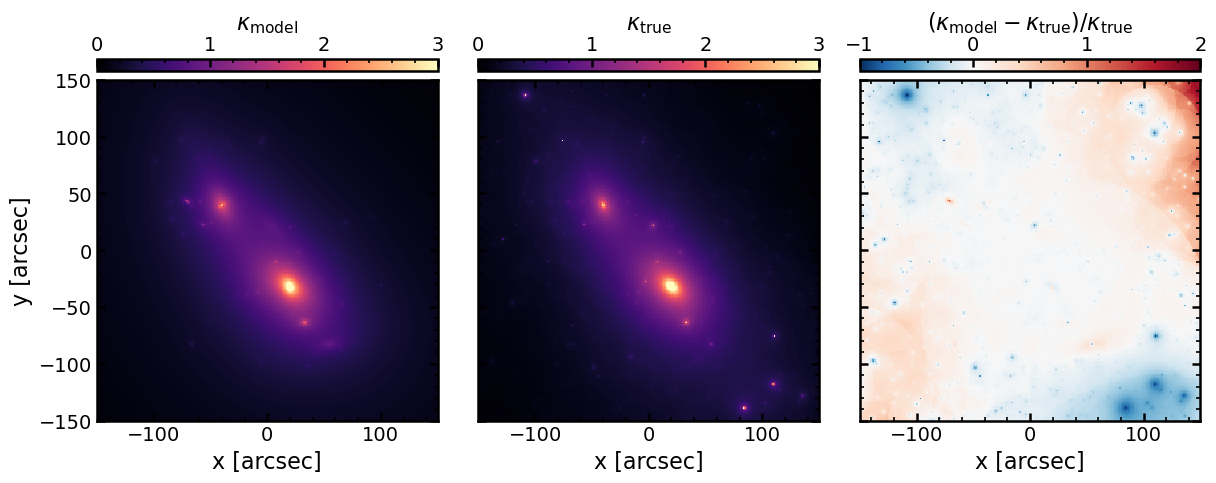

Wrote /home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 1000)S(1000, 500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit/ares_truth_recovery_kappa_model_truth_fractional_residual.pdf


In [21]:
previous_show = plotting._SHOW_PLOTS
plotting._SHOW_PLOTS = True
try:
    plotting._plot_kappa_model_truth_fractional_residual_from_grid(
        RUN_DIR,
        kappa_true,
        model_kappa,
        x_arcsec,
        y_arcsec,
        z_source,
    )
finally:
    plotting._SHOW_PLOTS = previous_show
print(f"Wrote {KAPPA_OUTPUT_PDF}")

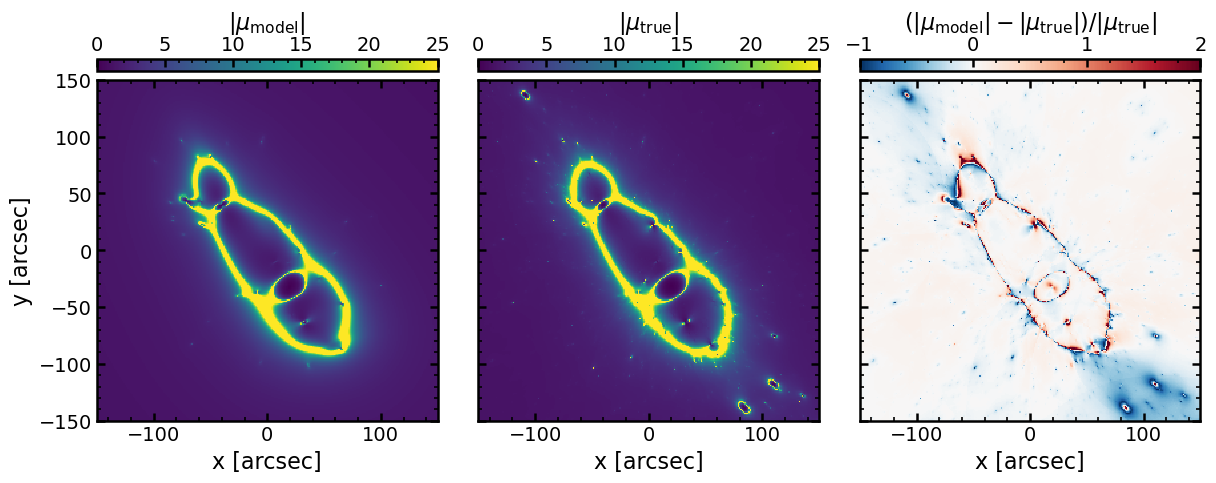

Wrote /home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 1000)S(1000, 500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit/ares_truth_recovery_mu_model_truth_fractional_residual.pdf


In [22]:
previous_show = plotting._SHOW_PLOTS
plotting._SHOW_PLOTS = True
try:
    plotting._plot_abs_mu_model_truth_fractional_residual_from_grid(
        RUN_DIR,
        abs_mu_true,
        model_abs_mu,
        x_arcsec,
        y_arcsec,
        z_source,
    )
finally:
    plotting._SHOW_PLOTS = previous_show
print(f"Wrote {MU_OUTPUT_PDF}")

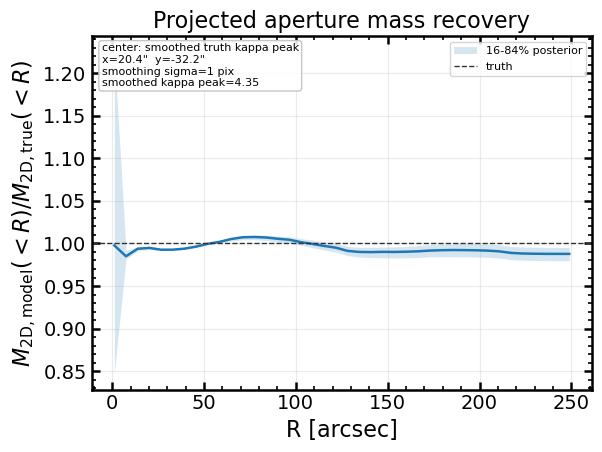

Wrote /home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 1000)S(1000, 500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit/ares_truth_recovery_m2d_aperture_ratio.pdf


In [23]:
aperture_profile_path = require_file(RUN_DIR / "tables" / "truth_recovery_m2d_aperture_profile.csv")
aperture_profile = pd.read_csv(aperture_profile_path)
if aperture_profile.empty:
    raise ValueError(f"Aperture profile table is empty: {aperture_profile_path}")

center_row = aperture_profile.iloc[0]

def optional_float(row, key):
    if key not in row.index:
        return float("nan")
    value = pd.to_numeric(pd.Series([row[key]]), errors="coerce").iloc[0]
    return float(value) if pd.notna(value) else float("nan")

aperture_center = {
    "center_mode": str(center_row["center_mode"]),
    "center_x_arcsec": float(center_row["center_x_arcsec"]),
    "center_y_arcsec": float(center_row["center_y_arcsec"]),
    "center_catalog_id": "" if pd.isna(center_row.get("center_catalog_id", "")) else str(center_row.get("center_catalog_id", "")),
    "center_catalog_mag": optional_float(center_row, "center_catalog_mag"),
    "center_smoothing_sigma_pix": optional_float(center_row, "center_smoothing_sigma_pix"),
    "center_smoothed_kappa_peak": optional_float(center_row, "center_smoothed_kappa_peak"),
}
previous_show = plotting._SHOW_PLOTS
plotting._SHOW_PLOTS = True
try:
    plotting._plot_truth_recovery_m2d_aperture_ratio(RUN_DIR, aperture_profile, aperture_center)
finally:
    plotting._SHOW_PLOTS = previous_show
if APERTURE_OUTPUT_PDF.exists():
    print(f"Wrote {APERTURE_OUTPUT_PDF.resolve()}")


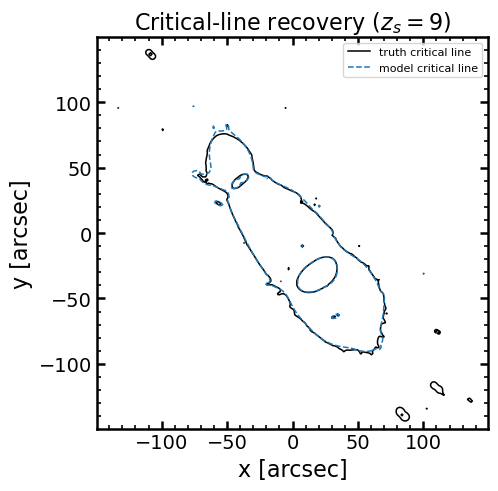

Wrote /home/dutra/dev/burkelenscluster/results/jun24l_anistropic/ares_PD0.1_TOPK_5_0.1_T(8, 8)W(5000, 1000)S(1000, 500)maglikelihoodTrue/ares_S1local-jacobian_S2critical-arc-anisotropic/stage2_free_source_forward_fit/ares_truth_recovery_critical_line_recovery.pdf


In [24]:
fig, ax = plt.subplots(figsize=(6.0, 5.2))
legend_handles = []
for determinant, color, linestyle, label in [
    (truth_det_a, "black", "-", "truth critical line"),
    (model_det_a, "tab:blue", "--", "model critical line"),
]:
    if not plotting._has_zero_contour(determinant):
        continue
    ax.contour(
        x_arcsec,
        y_arcsec,
        determinant,
        levels=[0.0],
        colors=[color],
        linestyles=[linestyle],
        linewidths=[1.1],
    )
    legend_handles.append(Line2D([0], [0], color=color, linestyle=linestyle, linewidth=1.1, label=label))

if not legend_handles:
    ax.text(0.5, 0.5, "No zero-determinant critical line in grid.", ha="center", va="center", transform=ax.transAxes)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x [arcsec]")
ax.set_ylabel("y [arcsec]")
ax.set_title(fr"Critical-line recovery ($z_s={z_source:g}$)")
if legend_handles:
    ax.legend(handles=legend_handles, loc="best", fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_PDF, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Wrote {OUTPUT_PDF}")